### Discovery

--- 
### Data preparation


First we will import the required modules. They are:
- Pandas
- Seaborn
- Statsmodels.api
- Sklearn.model_selection - train_test_split

In [3]:
# Import required modules. 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

In [15]:
# Import the first dataset and set the date as the index
health_df = pd.read_csv("healthcaredata/healthcare_dataset.csv")
health_df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [16]:
health_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [17]:
# Extract only the required rows
health_df = health_df[["Age","Date of Admission", "Discharge Date","Billing Amount"]]
health_df.head()

,Age,Date of Admission,Discharge Date,Billing Amount
0,30,2024-01-31,2024-02-02,18856.281306
1,62,2019-08-20,2019-08-26,33643.327287
2,76,2022-09-22,2022-10-07,27955.096079
3,28,2020-11-18,2020-12-18,37909.782410
4,43,2022-09-19,2022-10-09,14238.317814


In [18]:
# Convert date columns to datetime datatype
cols = ['Date of Admission', 'Discharge Date']
health_df['Date of Admission'] = pd.to_datetime(health_df['Date of Admission'])
health_df['Discharge Date'] = pd.to_datetime(health_df['Discharge Date'])
health_df["Billing Amount"] = health_df["Billing Amount"].round(2)
health_df.head()

,Age,Date of Admission,Discharge Date,Billing Amount
0,30,2024-01-31,2024-02-02,18856.28
1,62,2019-08-20,2019-08-26,33643.33
2,76,2022-09-22,2022-10-07,27955.10
3,28,2020-11-18,2020-12-18,37909.78
4,43,2022-09-19,2022-10-09,14238.32


In [24]:
health_df["Date Diff"] = (health_df["Discharge Date"] - health_df["Date of Admission"]).dt.days
health_df.head()

,Age,Date of Admission,Discharge Date,Billing Amount,Date Diff
0,30,2024-01-31,2024-02-02,18856.28,2
1,62,2019-08-20,2019-08-26,33643.33,6
2,76,2022-09-22,2022-10-07,27955.10,15
3,28,2020-11-18,2020-12-18,37909.78,30
4,43,2022-09-19,2022-10-09,14238.32,20


In [ ]:
health_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Age                55500 non-null  int64         
 1   Date of Admission  55500 non-null  datetime64[ns]
 2   Discharge Date     55500 non-null  datetime64[ns]
 3   Billing Amount     55500 non-null  float64       
 4   Date Diff          55500 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(2)
memory usage: 2.1 MB


--- 
### Model planning
You will now need to understand which variables have a relationship from the prepared data. Identifying the strength and direction of the relationships will help you to build a useful model, within the remit of the task. <br><br>
Create a correlation matrix, to establish which variables you wish to use. We will only use 1 indepednent and 1 depedant variable for this model. 

In [32]:
# Use price as dependent and select another appopriate variable to predict the output. health_corr = health_df.corr()
health_corr = health_df.corr()
health_corr

,Age,Date Diff,Billing Amount
Age,1.000000,0.008220,-0.003832
Date Diff,0.008220,1.000000,-0.005602
Billing Amount,-0.003832,-0.005602,1.000000


<Axes: >

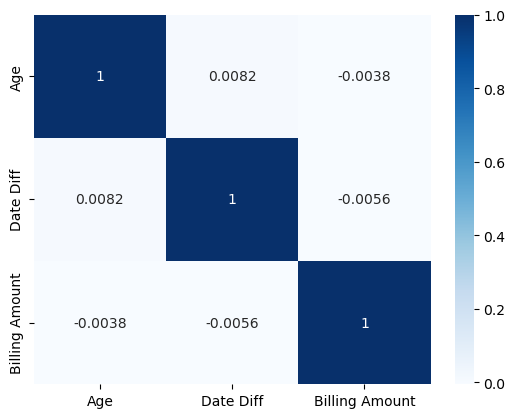

In [5]:
# (Optional) Generate the matrix as a heatmap visual
health_corr = health_df.corr()
sns.heatmap(health_corr, annot=True, cmap="Blues")